### Manual Signal Preprocessing 

In [4]:
from collections import deque
import matplotlib.pyplot as plt
import numpy as np

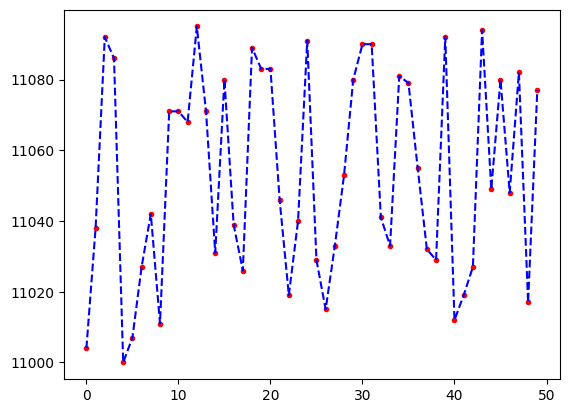

In [5]:
# synthetic signal
signal_length = 50
data_buffer = deque(maxlen=signal_length)
data_buffer.extend( np.random.randint(11000,11100,signal_length))
plt.plot(data_buffer,'r.')
plt.plot(data_buffer,'b--')
plt.show()

In [6]:
def convolve(signal:list, filter:list=[1, 1, 1]):
    """returns convolved signal with filter

    Args:
        signal (list): _description_
        filter (list, optional): _description_. Defaults to [1, 1, 1] moving average.
    """
    signal = np.array(signal)
    filter = np.array(filter)
    
    filter_sum = np.sum(np.abs(filter))
    filter_length = len(filter)
    signal_length = len(signal)
    filtered_signal = np.zeros(signal_length)
 
    for i in range(signal_length-1,filter_length, -1):
        filtered_signal[i] = np.dot(signal[i-filter_length:i],filter) / filter_sum
  

    return filtered_signal
    

In [7]:
filtered = convolve(data_buffer,filter=[-1,0,1]) # differential Filter
#filtered = convolve(filtered,filter=[1,1,1]) # Moving average Filter
filtered = filtered**2

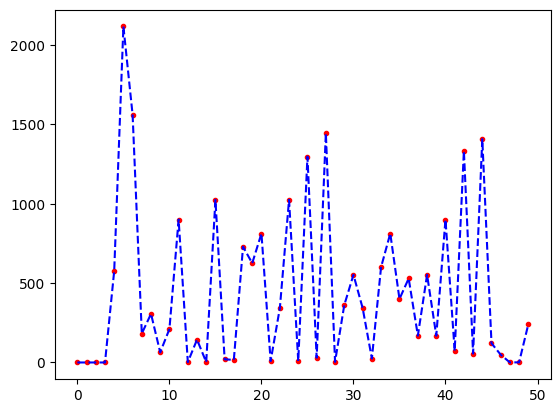

In [8]:
plt.plot(filtered,'r.')
plt.plot(filtered,'b--')
plt.show()

In [9]:
def peak_detector(signal, min_time = 30, min_threshold= 1):
    """
    idea is to find local maxima and filter out based on time duration between RR, peak minimum threshold
    min_time (distance in samples): 30
    """
    indices = []
    values = []
    for i in range(1, len(signal)-1):
        
        # skip low peaks
        if signal[i] < min_threshold:
            continue
        
        # basic difference
        if (signal[i] > signal[i-1]) and (signal[i] > signal[i+1]):
            # local maxima is found
            # check the last beat time
            if len(indices) > 0:
                last_beat_time = indices[-1] 
                current_beat_time = i 
                if current_beat_time - last_beat_time > min_time:
                    indices.append(i)
                    values.append(signal[i])
            else:
                indices.append(i)
                values.append(signal[i])
    return indices, values

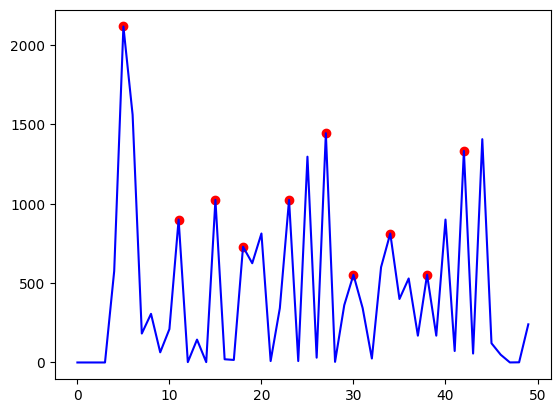

In [14]:
max_peak = np.max(filtered)
peaks, vals = peak_detector(filtered, min_time = 2, min_threshold=max_peak * 0.2)
    
plt.plot(filtered,'b-')
plt.scatter(peaks,vals,c='r')
plt.show()

---